<a href="https://colab.research.google.com/github/ThuanNP/dann-mnist-mnistm/blob/main/notebooks/dann_mnist_to_mnistm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ThuanNP/dann-mnist-mnistm/blob/main/notebooks/dann_mnist_to_mnistm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tái lập DANN trên MNIST → MNIST-M

Notebook tái lập thí nghiệm MNIST → MNIST-M của Ganin và Lempitsky (2015; bản arXiv 2014, sau đây gọi là bản ICML): dựng dữ liệu, huấn luyện ba mô hình
và phân tích kết quả. Phương pháp của Ganin và Lempitsky về sau được Ganin và cộng sự (2016; sau đây gọi là bản JMLR) gọi là mạng nơ-ron
đối kháng miền (Domain-Adversarial Neural Network, DANN); phần sau dùng tên này. Mỗi bước kèm công thức
tương ứng trong bài báo. Số phương trình, mục, hình và phụ lục của Ganin và Lempitsky (2015) ghi theo bản
[arXiv:1409.7495](https://arxiv.org/abs/1409.7495).

Cách chạy trên Google Colab: chọn *Runtime > Change runtime type > T4 GPU*, rồi *Runtime > Run all*. Notebook tự
tải MNIST và BSDS500, không cần cài thêm thư viện. Thời gian huấn luyện từng mô hình ghi ở bảng kết quả mục 8.1.

Ba mô hình dùng chung một kiến trúc:

| Mô hình | Dữ liệu huấn luyện | Vai trò |
| :--- | :--- | :--- |
| `baseline` (mô hình cơ sở) | MNIST có nhãn | Cận dưới, không thích ứng |
| `dann` | MNIST có nhãn và MNIST-M không nhãn | Thích ứng tên miền không giám sát |
| `target` | MNIST-M có nhãn | Cận trên, học trực tiếp trên miền đích |

Mã trong notebook chép từ gói `da_demo` của kho mã (repository)
[ThuanNP/dann-mnist-mnistm](https://github.com/ThuanNP/dann-mnist-mnistm), chỉ đổi tham số dòng lệnh thành
tham số hàm: dựng MNIST-M (`make_mnistm.py`), tiền xử lý và `Dataset` (`data.py`), kiến trúc (`models.py`), cố
định seed (`seed.py`), đánh giá (`evaluate.py`), bộ nạp `DataLoader`, vòng huấn luyện và quy tắc chọn epoch
(`train.py`). Kho mã còn có ứng dụng Streamlit, trọng số đã huấn luyện và kết quả ba seed.

## 1. Bài toán và cơ sở lý thuyết

### 1.1. Thích ứng tên miền không giám sát

Trong thích ứng tên miền không giám sát (unsupervised domain adaptation), miền nguồn $\mathcal{D}_s$ có mẫu gán
nhãn $\{(x_i, y_i)\}_{i=1}^{n_s}$, còn miền đích $\mathcal{D}_t$ chỉ có mẫu không nhãn $\{x_j\}_{j=1}^{n_t}$. Hai
miền chung không gian nhãn (10 chữ số) nhưng khác phân phối đầu vào: $P_s(X) \neq P_t(X)$. Mục tiêu là một bộ
phân loại có sai số thấp trên miền đích. Ở đây miền nguồn là MNIST (chữ số trắng trên nền đen), miền đích là
MNIST-M (chữ số trộn với mảnh ảnh màu), $n_s = n_t = 60\,000$.

### 1.2. Cận trên của rủi ro miền đích

Ganin và cộng sự (2016, Định lý 2), dựa trên Ben-David và cộng sự (2006), phát biểu: với lớp giả thuyết
$\mathcal{H}$ có chiều VC (Vapnik-Chervonenkis dimension) $d$, với xác suất $1-\delta$ trên cách chọn mẫu
$S \sim (\mathcal{D}_s)^n$ và $T \sim (\mathcal{D}_t^X)^n$, mọi $\eta \in \mathcal{H}$ thỏa

$$
R_{\mathcal{D}_t}(\eta) \le R_S(\eta)
+ \sqrt{\frac{4}{n}\left(d \log\frac{2en}{d} + \log\frac{4}{\delta}\right)}
+ \hat{d}_{\mathcal{H}}(S, T)
+ 4\sqrt{\frac{1}{n}\left(d \log\frac{2n}{d} + \log\frac{4}{\delta}\right)}
+ \beta,
\qquad
\beta \ge \inf_{\eta^* \in \mathcal{H}} \left[R_{\mathcal{D}_s}(\eta^*) + R_{\mathcal{D}_t}(\eta^*)\right].
$$

Số hạng $\hat{d}_{\mathcal{H}}(S, T)$ là độ phân kỳ $\mathcal{H}$ thực nghiệm (empirical $\mathcal{H}$-divergence)
giữa hai mẫu: hai miền càng khó phân biệt bằng một bộ phân loại trong $\mathcal{H}$ thì số hạng này càng nhỏ.
Để kiểm soát số hạng này, Ganin và cộng sự (2016, mục 3.3) tìm một biểu diễn trong đó mẫu của hai miền khó phân
biệt nhất có thể, đồng thời giữ rủi ro nguồn $R_S(\eta)$ thấp.

### 1.3. Kiến trúc và hàm mục tiêu

DANN gồm bộ trích đặc trưng $G_f(\cdot;\theta_f)$, bộ dự đoán nhãn $G_y(\cdot;\theta_y)$ và bộ phân loại miền
$G_d(\cdot;\theta_d)$. Nhãn miền $d_i = 0$ với mẫu nguồn, $d_i = 1$ với mẫu đích. Ganin và Lempitsky (2015,
phương trình 1 đến 3) tìm điểm yên ngựa của phiếm hàm

$$
E(\theta_f,\theta_y,\theta_d) = \sum_{i:\,d_i=0} L_y^i(\theta_f,\theta_y) - \lambda \sum_{i=1}^{N} L_d^i(\theta_f,\theta_d),
$$

$$
(\hat\theta_f, \hat\theta_y) = \arg\min_{\theta_f,\theta_y} E(\theta_f,\theta_y,\hat\theta_d),
\qquad
\hat\theta_d = \arg\max_{\theta_d} E(\hat\theta_f,\hat\theta_y,\theta_d).
$$

$L_y$ là mất mát hồi quy logistic đa lớp (entropy chéo), $L_d$ là entropy chéo nhị phân. Tại điểm yên ngựa,
$\theta_y$ cực tiểu mất mát dự đoán nhãn và $\theta_d$ cực tiểu mất mát phân loại miền. $\theta_f$ vừa cực tiểu
mất mát dự đoán nhãn (đặc trưng có tính phân biệt), vừa cực đại mất mát phân loại miền (đặc trưng bất biến theo
miền). $\lambda$ điều hòa hai mục tiêu.

### 1.4. Tầng đảo ngược gradient

Điểm yên ngựa có thể tìm được dưới dạng điểm dừng (stationary point) của các cập nhật ngẫu nhiên (phương trình 4
đến 6), với $\mu$ là tốc độ học:

$$
\theta_f \leftarrow \theta_f - \mu\left(\frac{\partial L_y^i}{\partial \theta_f} - \lambda \frac{\partial L_d^i}{\partial \theta_f}\right),
\qquad
\theta_y \leftarrow \theta_y - \mu \frac{\partial L_y^i}{\partial \theta_y},
\qquad
\theta_d \leftarrow \theta_d - \mu \frac{\partial L_d^i}{\partial \theta_d}.
$$

Tầng đảo ngược gradient (Gradient Reversal Layer, GRL) đặt giữa $G_f$ và $G_d$. Ganin và Lempitsky định nghĩa GRL
là một "giả hàm" (pseudo-function) $R_\lambda(x)$, xác định bởi hai phương trình không tương thích với nhau, mỗi
phương trình mô tả một chiều lan truyền (phương trình 7, 8): $R_\lambda(x) = x$ và
$\dfrac{dR_\lambda}{dx} = -\lambda I$. Với GRL, hạ gradient ngẫu nhiên (Stochastic Gradient Descent, SGD) thông
thường trên

$$
\tilde{E}(\theta_f,\theta_y,\theta_d) = \sum_{i:\,d_i=0} L_y\big(G_y(G_f(x_i)), y_i\big) + \sum_{i=1}^{N} L_d\big(G_d(R_\lambda(G_f(x_i))), d_i\big)
$$

thực hiện đúng ba cập nhật trên (phương trình 9). Hàm `train` ở mục 6 cài phiếm hàm này bằng
`loss = loss_y + loss_d`; mỗi số hạng lấy trung bình theo batch (`F.cross_entropy`,
`F.binary_cross_entropy_with_logits`), giống `da_demo/train.py`. Phiếm hàm trên lấy tổng $L_d$ trên $N$ mẫu,
gấp đôi số mẫu nguồn, còn phương trình 10 của bản JMLR chuẩn hóa $L_d$ theo số mẫu của từng miền. So với cả hai,
việc lấy trung bình `loss_d` trên 128 ảnh làm trọng số hiệu dụng của $L_d$ giảm một nửa: $\lambda_p/2$ với $G_f$
(qua GRL) và $1/2$ với $G_d$.

## 2. Cấu hình và môi trường

Siêu tham số lấy từ mục 4 và Phụ lục C của Ganin và Lempitsky (2015) và trùng giá trị mặc định của
`da_demo.train`. Bài báo không cố định ba lựa chọn sau:

- Số seed (giá trị khởi tạo ngẫu nhiên). `SEEDS = [42]` huấn luyện mỗi mô hình một lần; `[42, 43, 44]` lặp lại
  ba seed như kho mã.
- Cách tính trung bình khi tiền xử lý. Bài báo chỉ ghi phép trừ trung bình (mean subtraction). `NORM = "half"`
  trừ 0,5 ở mỗi kênh; `NORM = "mean"` trừ trung bình từng kênh trên tập huấn luyện gộp của hai miền (công thức
  ở mục 3.4).
- Số bước huấn luyện cho MNIST → MNIST-M. `EPOCHS = 20` là số lượt duyệt tập huấn luyện (epoch) có nhãn; lịch
  tốc độ học và $\lambda$ tính theo tổng số bước.

`WORKERS = 2` là số tiến trình nạp dữ liệu của `DataLoader`, bằng giá trị mặc định `--workers` của kho mã. Số tiến
trình ảnh hưởng đến cách `DataLoader` dùng bộ sinh số ngẫu nhiên, nên cần giữ nguyên khi đối chiếu với kho mã.
`MAX_STEPS` giới hạn số bước khi chạy thử (tương ứng `--max-steps`); huấn luyện đầy đủ đặt `None`.

In [67]:
import io
import json
import math
import os
import platform
import random
import subprocess
import tarfile
import time
import urllib.request
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEEDS = [42]           # [42, 43, 44] để lặp lại ba seed
NORM = "half"          # "half" hoặc "mean"
EPOCHS = 20
BATCH = 128            # tổng batch; DANN: 64 ảnh nguồn + 64 ảnh đích mỗi bước
MU0, ALPHA, BETA = 0.01, 10.0, 0.75   # lịch tốc độ học (Phụ lục C)
GAMMA = 10.0                          # lịch hệ số thích ứng (phương trình 14)
MOMENTUM = 0.9
MNISTM_SEED = 0        # seed cắt mảnh BSDS500 khi dựng MNIST-M
WORKERS = 2            # số tiến trình của DataLoader
MAX_STEPS = None       # ví dụ 50 để chạy thử
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("Không có GPU: chọn Runtime > Change runtime type > T4 GPU (chạy trên CPU rất chậm).")


def environment(device):
    """Môi trường chạy: Python, hệ điều hành, torch, CUDA, cuDNN, GPU, commit git."""
    try:
        commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=".",
                                capture_output=True, text=True, check=True).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        commit = None
    return {
        "python": platform.python_version(),
        "os": platform.platform(),
        "torch": str(torch.__version__),
        "cuda": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "device": torch.cuda.get_device_name(device) if device.type == "cuda" else "cpu",
        "git_commit": commit,
    }


pd.DataFrame([environment(device)])

,python,os,torch,cuda,cudnn,device,git_commit
0,3.13.15,Linux-6.6.122+-x86_64-with-glibc2.39,2.11.0+cu128,12.8,91900,Tesla T4,None


In [68]:
# da_demo/seed.py
def set_seed(seed: int) -> torch.Generator:
    """Cố định seed cho random, NumPy, PyTorch; trả về Generator cho DataLoader."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    g = torch.Generator()
    g.manual_seed(seed)
    return g


def seed_worker(worker_id: int) -> None:
    """Seed cho từng worker của DataLoader."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## 3. Dữ liệu

### 3.1. MNIST (miền nguồn)

MNIST (LeCun và cộng sự, 1998) gồm ảnh xám 28×28 của chữ số viết tay: 60.000 ảnh huấn luyện và 10.000 ảnh kiểm
thử. Để dùng chung kiến trúc với MNIST-M, mỗi ảnh được chuyển thành ảnh ba kênh giống nhau (lớp `MNISTRGB`,
mục 3.4).

In [69]:
mnist_tr = datasets.MNIST(DATA_DIR, train=True, download=True)
mnist_te = datasets.MNIST(DATA_DIR, train=False, download=True)
print("MNIST train", tuple(mnist_tr.data.shape), " test", tuple(mnist_te.data.shape))

MNIST train (60000, 28, 28)  test (10000, 28, 28)


### 3.2. Dựng MNIST-M (miền đích)

Ganin và Lempitsky (2015, mục 4.1) tạo MNIST-M bằng cách trộn chữ số MNIST với mảnh cắt ngẫu nhiên từ ảnh màu
của BSDS500 (Arbelaez và cộng sự, 2011). Với ảnh chữ số $I^1$ (lặp thành ba kênh) và mảnh ảnh màu $I^2$ cùng
kích thước, ảnh kết quả là

$$
I^{\text{out}}_{ijk} = \left| I^1_{ijk} - I^2_{ijk} \right|,
$$

với $i, j$ là tọa độ điểm ảnh và $k$ là chỉ số kênh. Tại điểm ảnh thuộc nét chữ ($I^1 = 255$), màu của mảnh ảnh
bị đảo; tại điểm ảnh nền ($I^1 = 0$), mảnh ảnh giữ nguyên. Chữ số vì thế mang màu và kết cấu của ảnh chụp thay
vì trắng trên nền đen.

Hai bản công bố không nêu thêm chi tiết cài đặt. Hàm `make_mnistm` dưới đây tương đương hàm `main` của
`da_demo/make_mnistm.py`: một bộ sinh số `np.random.default_rng(0)` dùng lần lượt cho tập huấn luyện rồi tập kiểm
thử; mảnh 28×28 cắt ở độ phân giải gốc của ảnh BSDS500; nền của tập huấn luyện lấy từ 200 ảnh BSDS500 `train`,
nền của tập kiểm thử lấy từ 200 ảnh `test`, nên hai tập không chung ảnh nền. Kết quả ghi vào
`data/mnist_m_gen/{train,test}.npz`, cùng định dạng với kho mã. Tệp BSDS500 (khoảng 70 MB) tải từ trang BSDS500
của Đại học California, Berkeley.

In [70]:
# da_demo/make_mnistm.py
BSDS_URL = "https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz"
SIZE = 28


def bsds_images(data_dir: Path, split: str) -> list:
    tgz = data_dir / "BSR_bsds500.tgz"
    if not tgz.exists():
        urllib.request.urlretrieve(BSDS_URL, tgz)
    out = []
    with tarfile.open(tgz) as tar:
        for m in tar.getmembers():
            if f"BSDS500/data/images/{split}/" in m.name and m.name.endswith(".jpg"):
                out.append(np.asarray(Image.open(tar.extractfile(m)).convert("RGB")))
    return out


def blend(digits: np.ndarray, backgrounds: list, rng: np.random.Generator) -> np.ndarray:
    # I_out = |I1 - I2|, I2 là mảnh 28x28 cắt ngẫu nhiên từ một ảnh nền chọn ngẫu nhiên
    out = np.empty((len(digits), SIZE, SIZE, 3), dtype=np.uint8)
    for n, d in enumerate(digits):
        bg = backgrounds[rng.integers(len(backgrounds))]
        y = rng.integers(bg.shape[0] - SIZE + 1)
        x = rng.integers(bg.shape[1] - SIZE + 1)
        patch = bg[y:y + SIZE, x:x + SIZE].astype(np.int16)
        out[n] = np.abs(d[:, :, None].astype(np.int16) - patch).astype(np.uint8)
    return out


def make_mnistm(data_dir=DATA_DIR, seed=MNISTM_SEED):
    """Như main() của da_demo.make_mnistm; trả thêm ảnh và ảnh nền để minh họa."""
    rng = np.random.default_rng(seed)
    out_dir = data_dir / "mnist_m_gen"
    out_dir.mkdir(parents=True, exist_ok=True)
    built = {}
    for split, bsds_split in [("train", "train"), ("test", "test")]:
        mnist = datasets.MNIST(root=str(data_dir), train=split == "train", download=True)
        backgrounds = bsds_images(data_dir, bsds_split)
        images = blend(mnist.data.numpy(), backgrounds, rng)
        np.savez_compressed(out_dir / f"{split}.npz", images=images, labels=mnist.targets.numpy())
        print(split, images.shape, f"nền: {len(backgrounds)} ảnh BSDS500 {bsds_split}")
        built[split] = (images, backgrounds)
    return built


t0 = time.time()
built = make_mnistm()
(mnistm_tr, bg_train), (mnistm_te, bg_test) = built["train"], built["test"]
print(f"({time.time() - t0:.0f} s)")

train (60000, 28, 28, 3) nền: 200 ảnh BSDS500 train
test (10000, 28, 28, 3) nền: 200 ảnh BSDS500 test
(10 s)


Hình 1 minh họa phép trộn trên ba chữ số: cột giữa là mảnh ảnh nền $I^2$, cột phải là
$\left| I^1 - I^2 \right|$. Các mảnh trong hình cắt bằng một bộ sinh số ngẫu nhiên riêng, không ảnh hưởng đến
tập dữ liệu vừa dựng.

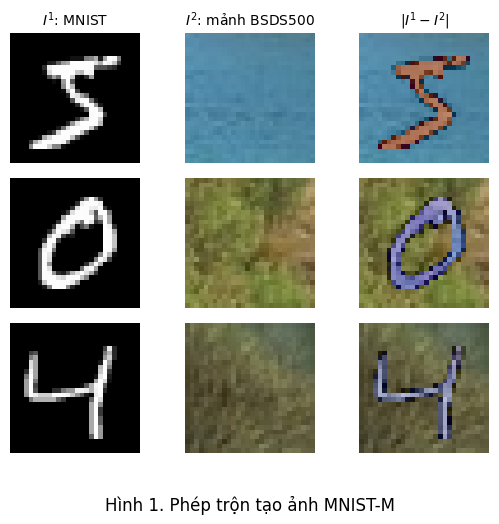

In [71]:
demo_rng = np.random.default_rng(123)
fig, ax = plt.subplots(3, 3, figsize=(5.4, 5.4))
for r, idx in enumerate([0, 1, 2]):
    d = mnist_tr.data[idx].numpy()
    bg = bg_train[demo_rng.integers(len(bg_train))]
    y, x = demo_rng.integers(bg.shape[0] - SIZE + 1), demo_rng.integers(bg.shape[1] - SIZE + 1)
    patch = bg[y:y + SIZE, x:x + SIZE]
    out = np.abs(d[:, :, None].astype(np.int16) - patch.astype(np.int16)).astype(np.uint8)
    for c, (img, title) in enumerate([(d, "$I^1$: MNIST"), (patch, "$I^2$: mảnh BSDS500"),
                                      (out, "$|I^1 - I^2|$")]):
        ax[r, c].imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax[r, c].axis("off")
        if r == 0:
            ax[r, c].set_title(title, fontsize=10)
fig.suptitle("Hình 1. Phép trộn tạo ảnh MNIST-M", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 3.3. Mô tả dữ liệu

Hai miền dùng chung nhãn: ảnh MNIST-M thứ $n$ mang nhãn của ảnh MNIST thứ $n$, nên phân phối lớp của hai miền
trùng nhau. Hai miền khác nhau ở phân phối đầu vào $P(X)$: màu, độ tương phản và kết cấu nền.

In [72]:
y_tr, y_te = mnist_tr.targets.numpy(), mnist_te.targets.numpy()
sizes = pd.DataFrame({
    "Miền": ["Nguồn", "Đích"], "Bộ dữ liệu": ["MNIST", "MNIST-M"],
    "Ảnh huấn luyện": [len(y_tr), len(mnistm_tr)], "Ảnh kiểm thử": [len(y_te), len(mnistm_te)],
    "Kích thước": ["28×28×1 (chuyển thành 3 kênh)", "28×28×3"],
    "Nhãn dùng khi huấn luyện DANN": ["Có", "Không"]})
display(sizes)

counts = pd.DataFrame({"Huấn luyện": np.bincount(y_tr), "Kiểm thử": np.bincount(y_te)})
counts.index.name = "Chữ số"
display(counts.T)

,Miền,Bộ dữ liệu,Ảnh huấn luyện,Ảnh kiểm thử,Kích thước,Nhãn dùng khi huấn luyện DANN
0,Nguồn,MNIST,60000,10000,28×28×1 (chuyển thành 3 kênh),Có
1,Đích,MNIST-M,60000,10000,28×28×3,Không


Chữ số,0,1,2,3,4,5,6,7,8,9
Huấn luyện,5923,6742,5958,6131,5842,5421,5918,6265,5851,5949
Kiểm thử,980,1135,1032,1010,982,892,958,1028,974,1009


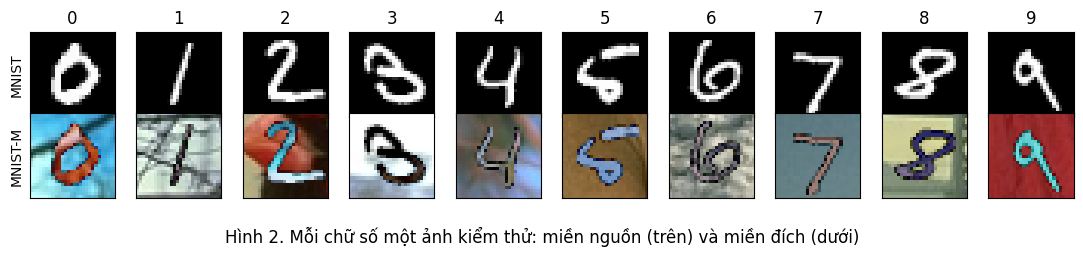

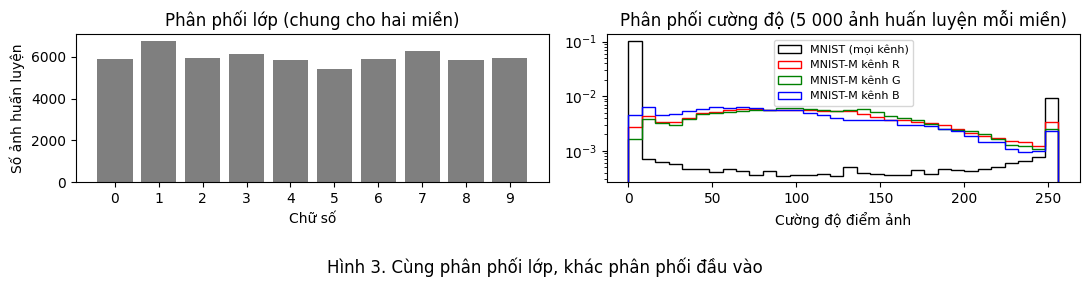

Kênh,R,G,B
"Trung bình cường độ (thang [0, 1])",,,
MNIST,0.1307,0.1307,0.1307
MNIST-M,0.4356,0.4391,0.3838


In [73]:
fig, ax = plt.subplots(2, 10, figsize=(11, 2.6))
for k in range(10):
    i = int(np.where(y_te == k)[0][0])
    ax[0, k].imshow(mnist_te.data[i], cmap="gray")
    ax[1, k].imshow(mnistm_te[i])
    ax[0, k].set_title(str(k))
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
ax[0, 0].set_ylabel("MNIST")
ax[1, 0].set_ylabel("MNIST-M")
fig.suptitle("Hình 2. Mỗi chữ số một ảnh kiểm thử: miền nguồn (trên) và miền đích (dưới)", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].bar(range(10), counts["Huấn luyện"], color="tab:gray")
ax[0].set_xticks(range(10)); ax[0].set_xlabel("Chữ số"); ax[0].set_ylabel("Số ảnh huấn luyện")
ax[0].set_title("Phân phối lớp (chung cho hai miền)")
bins = np.arange(0, 257, 8)
ax[1].hist(mnist_tr.data[:5000].numpy().ravel(), bins=bins, density=True, histtype="step",
           color="k", label="MNIST (mọi kênh)")
for k, c in enumerate(["red", "green", "blue"]):
    ax[1].hist(mnistm_tr[:5000, :, :, k].ravel(), bins=bins, density=True, histtype="step",
               color=c, label=f"MNIST-M kênh {'RGB'[k]}")
ax[1].set_yscale("log"); ax[1].set_xlabel("Cường độ điểm ảnh"); ax[1].legend(fontsize=8)
ax[1].set_title("Phân phối cường độ (5 000 ảnh huấn luyện mỗi miền)")
fig.suptitle("Hình 3. Cùng phân phối lớp, khác phân phối đầu vào", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

stats = pd.DataFrame({
    "MNIST": [mnist_tr.data.float().div(255).mean().item()] * 3,
    "MNIST-M": mnistm_tr.mean(axis=(0, 1, 2)) / 255}, index=["R", "G", "B"])
stats.index.name = "Kênh"
display(stats.round(4).T.rename_axis("Trung bình cường độ (thang [0, 1])"))

MNIST gần như chỉ có hai mức cường độ (nền 0, nét chữ gần 255), còn cường độ của MNIST-M trải trên toàn thang và
khác nhau giữa ba kênh. Mô hình chỉ học trên MNIST gặp lệch miền (domain shift) này khi dự đoán trên MNIST-M.

### 3.4. Tiền xử lý và tập dữ liệu

Ganin và Lempitsky (2015, mục 4) chỉ ghi ảnh được tiền xử lý bằng phép trừ trung bình. Với ảnh $x$ ở thang
$[0, 1]$, đầu vào của mạng là $x'_{ijk} = x_{ijk} - m_k$, với

- `NORM = "half"`: $m_k = 0{,}5$ ở mọi kênh;
- `NORM = "mean"`: $m_k = \dfrac{\sum_{x \in S_{\text{train}}} \sum_{i,j} x_{ijk} + \sum_{x \in T_{\text{train}}} \sum_{i,j} x_{ijk}}{(n_s + n_t) \cdot 28 \cdot 28}$,
  trung bình kênh $k$ trên tập huấn luyện gộp của hai miền (không dùng nhãn). Ảnh MNIST góp cùng một giá trị cho
  cả ba kênh. Với MNIST-M dựng ở mục 3.2, kho mã ghi $m = (0{,}2831;\ 0{,}2849;\ 0{,}2572)$ (`runs/gen-mean`).

Mã dưới đây chép từ `da_demo/data.py`, bỏ nhánh MNIST-M bản Hugging Face. `preprocess` đổi ảnh sang RGB, chuyển
về tensor thang $[0, 1]$ (`ToTensor`) rồi trừ $m_k$ (`Normalize` với độ lệch chuẩn 1). `MNISTRGB` và `MNISTMGen`
là `Dataset` của miền nguồn và miền đích; mỗi mẫu đi qua `preprocess` khi được lấy ra. `train_channel_mean`
tính $m_k$ bằng số thực 32 bit và làm tròn 6 chữ số thập phân. Hàm `train` ở mục 6 dựng lại các tập này ở mỗi
lần huấn luyện, như `da_demo.train`.

In [74]:
# da_demo/data.py (phần dùng cho MNIST và MNIST-M dựng lại)
IMG_SIZE = 28

# Mặc định trừ 0.5 mỗi kênh, giữ nguyên thang đo.
HALF_MEAN = (0.5, 0.5, 0.5)


@lru_cache(maxsize=None)
def _transform(mean: tuple) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=(1.0, 1.0, 1.0)),
    ])


def to_rgb(img: Image.Image) -> Image.Image:
    return img.convert("RGB")


def preprocess(img: Image.Image, mean=HALF_MEAN) -> torch.Tensor:
    """Tiền xử lý một ảnh bất kỳ (dùng chung cho huấn luyện và ứng dụng Streamlit)."""
    return _transform(tuple(mean))(to_rgb(img))


def train_channel_mean(root: Path, target: str = "mnist_m_gen") -> tuple:
    """Trung bình từng kênh (thang [0, 1]) trên tập train gộp của MNIST và MNIST-M dựng lại."""
    mnist = datasets.MNIST(root=str(root), train=True, download=True).data.float().div(255)
    sums = torch.full((3,), mnist.sum().item())
    count = mnist.numel()
    tgt = MNISTMGen(root, train=True)
    for img, _ in tgt.raw():
        x = transforms.functional.to_tensor(to_rgb(img).resize((IMG_SIZE, IMG_SIZE),
                                                               Image.BILINEAR))
        sums += x.sum(dim=(1, 2))
        count += IMG_SIZE * IMG_SIZE
    return tuple(round(v, 6) for v in (sums / count).tolist())


class MNISTRGB(Dataset):
    """MNIST chuyển sang 3 kênh để dùng chung kiến trúc với MNIST-M."""

    def __init__(self, root: Path, train: bool, mean=HALF_MEAN):
        self.ds = datasets.MNIST(root=str(root), train=train, download=True)
        self.mean = tuple(mean)

    def __len__(self) -> int:
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        return preprocess(img, self.mean), label


class MNISTMGen(Dataset):
    """MNIST-M tạo bằng make_mnistm (ảnh 28x28, 60.000 train, 10.000 test)."""

    def __init__(self, root: Path, train: bool, mean=HALF_MEAN):
        path = Path(root) / "mnist_m_gen" / ("train.npz" if train else "test.npz")
        if not path.exists():
            raise FileNotFoundError(f"Thiếu {path}; chạy ô dựng MNIST-M ở mục 3.2")
        d = np.load(path)
        self.images, self.labels, self.mean = d["images"], d["labels"].tolist(), tuple(mean)

    def __len__(self) -> int:
        return len(self.labels)

    def raw(self):
        for x, y in zip(self.images, self.labels):
            yield Image.fromarray(x), y

    def __getitem__(self, idx):
        return preprocess(Image.fromarray(self.images[idx]), self.mean), self.labels[idx]


def get_dataset(name: str, root: Path, train: bool, mean=HALF_MEAN) -> Dataset:
    if name == "mnist":
        return MNISTRGB(root, train, mean)
    if name == "mnist_m_gen":
        return MNISTMGen(root, train, mean)
    raise ValueError(f"Không có bộ dữ liệu {name}")


MEAN = HALF_MEAN if NORM == "half" else train_channel_mean(DATA_DIR)
print("NORM =", NORM, " m =", MEAN)
x0, y0 = get_dataset("mnist_m_gen", DATA_DIR, train=True, mean=MEAN)[0]
print("Một mẫu MNIST-M sau tiền xử lý:", tuple(x0.shape), x0.dtype, "nhãn", y0,
      f"giá trị trong [{x0.min():.3f}, {x0.max():.3f}]")

NORM = half  m = (0.5, 0.5, 0.5)
Một mẫu MNIST-M sau tiền xử lý: (3, 28, 28) torch.float32 nhãn 5 giá trị trong [-0.496, 0.414]


## 4. Mô hình

Kiến trúc cho MNIST theo Ganin và Lempitsky (2015, Phụ lục B, Hình 5(a)), mã chép từ `da_demo/models.py`:

- Bộ trích đặc trưng $G_f$: tích chập (conv) 5×5, 32 kênh → ReLU → gộp cực đại (max-pool) 2×2 → tích chập 5×5,
  48 kênh → ReLU → gộp cực đại 2×2.
- Bộ dự đoán nhãn $G_y$: tầng kết nối đầy đủ (FC) 100 → ReLU → FC 100 → ReLU → FC 10 → softmax (gộp trong hàm
  mất mát entropy chéo).
- Bộ phân loại miền $G_d$: GRL → FC 100 → ReLU → FC 1 (hồi quy logistic; hàm sigmoid gộp trong hàm mất mát).

GRL cài bằng `torch.autograd.Function`: chiều xuôi trả lại đầu vào, chiều ngược nhân gradient với $-\lambda$,
tức hai phương trình $R_\lambda(x) = x$ và $dR_\lambda/dx = -\lambda I$. Mô hình cơ sở và `target` dùng cùng lớp
`DANN` nhưng bỏ qua nhánh miền. Tên tham số trùng với kho mã, nên trọng số lưu từ notebook nạp được vào ứng dụng
Streamlit.

In [75]:
# da_demo/models.py
class GradReverse(torch.autograd.Function):
    """Gradient Reversal Layer: lan truyền xuôi giữ nguyên, lan truyền ngược nhân -lambda."""

    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x: torch.Tensor, lambd: float) -> torch.Tensor:
    return GradReverse.apply(x, lambd)


class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 48, kernel_size=5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Flatten(),
        )
        self.out_dim = 48 * 4 * 4

    def forward(self, x):
        return self.net(x)


class LabelPredictor(nn.Module):
    def __init__(self, in_dim: int, n_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 100), nn.ReLU(),
            nn.Linear(100, 100), nn.ReLU(),
            nn.Linear(100, n_classes),
        )

    def forward(self, f):
        return self.net(f)


class DomainClassifier(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 100), nn.ReLU(), nn.Linear(100, 1))

    def forward(self, f, lambd: float):
        return self.net(grad_reverse(f, lambd)).squeeze(1)


class DANN(nn.Module):
    """Dùng chung cho baseline (bỏ qua nhánh miền) và DANN."""

    def __init__(self, n_classes: int = 10):
        super().__init__()
        self.features = FeatureExtractor()
        self.classifier = LabelPredictor(self.features.out_dim, n_classes)
        self.domain = DomainClassifier(self.features.out_dim)

    def forward(self, x, lambd: float = 0.0, with_domain: bool = False):
        f = self.features(x)
        logits = self.classifier(f)
        if with_domain:
            return logits, self.domain(f, lambd)
        return logits

In [76]:
# Bảng kiến trúc: kích thước đầu ra và số tham số từng tầng
rows, m = [], DANN()
x = torch.zeros(1, 3, 28, 28)
for part, seq in [("G_f", m.features.net), ("G_y", m.classifier.net), ("G_d", m.domain.net)]:
    h = x if part == "G_f" else m.features(x)
    for layer in seq:
        h = layer(h)
        rows.append({"Thành phần": part, "Tầng": layer.__class__.__name__,
                     "Đầu ra": "×".join(map(str, h.shape[1:])),
                     "Tham số": sum(p.numel() for p in layer.parameters())})
arch = pd.DataFrame(rows)
display(arch)
print("Tổng số tham số:", sum(p.numel() for p in m.parameters()))

# Kiểm tra GRL: gradient của sum(R_lambda(x)) theo x phải bằng -lambda
xg = torch.randn(5, requires_grad=True)
grad_reverse(xg, 0.3).sum().backward()
print("GRL, lambda = 0.3: gradient =", xg.grad.tolist())
assert torch.allclose(xg.grad, torch.full_like(xg, -0.3))

,Thành phần,Tầng,Đầu ra,Tham số
0,G_f,Conv2d,32×24×24,2432
1,G_f,ReLU,32×24×24,0
2,G_f,MaxPool2d,32×12×12,0
3,G_f,Conv2d,48×8×8,38448
4,G_f,ReLU,48×8×8,0
5,G_f,MaxPool2d,48×4×4,0
6,G_f,Flatten,768,0
7,G_y,Linear,100,76900
8,G_y,ReLU,100,0
9,G_y,Linear,100,10100


Tổng số tham số: 205891
GRL, lambda = 0.3: gradient = [-0.30000001192092896, -0.30000001192092896, -0.30000001192092896, -0.30000001192092896, -0.30000001192092896]


## 5. Thiết lập huấn luyện

Gọi $p \in [0, 1]$ là tiến độ huấn luyện (training progress): $p = t / T$, với $t$ là số bước đã thực hiện và $T$
là tổng số bước. Theo Ganin và Lempitsky (2015):

- Tốc độ học (Phụ lục C): $\mu_p = \dfrac{\mu_0}{(1 + \alpha p)^{\beta}}$, với $\mu_0 = 0{,}01$, $\alpha = 10$,
  $\beta = 0{,}75$; SGD với động lượng (momentum) 0,9.
- Hệ số thích ứng (adaptation factor, phương trình 14): $\lambda_p = \dfrac{2}{1 + \exp(-\gamma p)} - 1$, với
  $\gamma = 10$. $\lambda$ tăng dần từ 0 đến 1 để giảm nhiễu từ bộ phân loại miền ở giai đoạn đầu huấn luyện.
- Batch 128. Với DANN, một nửa batch là ảnh nguồn có nhãn, nửa còn lại là ảnh đích không nhãn.

Một epoch là một lượt duyệt tập có nhãn. `DataLoader` bỏ batch cuối không đủ kích thước (`drop_last=True`), nên
DANN (64 ảnh nguồn mỗi bước) có $\lfloor 60\,000 / 64 \rfloor = 937$ bước mỗi epoch, còn mô hình cơ sở và `target`
(128 ảnh mỗi bước) có $\lfloor 60\,000 / 128 \rfloor = 468$ bước. Với 20 epoch, $T$ lần lượt là 18.740 và 9.360,
trùng trường `steps` trong kết quả của kho mã.

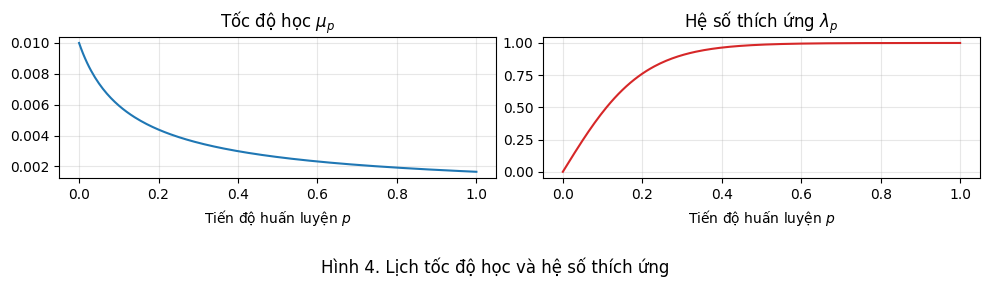

,p,mu_p,lambda_p
0,0.0,0.01000,0.0000
1,0.1,0.00595,0.4621
2,0.3,0.00354,0.9051
3,0.5,0.00261,0.9866
4,1.0,0.00166,0.9999


In [77]:
# da_demo/train.py
def lr_at(p, mu0=MU0, alpha=ALPHA, beta=BETA):
    return mu0 / (1.0 + alpha * p) ** beta


def lambda_at(p, gamma=GAMMA):
    return 2.0 / (1.0 + math.exp(-gamma * p)) - 1.0


ps = np.linspace(0, 1, 201)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(ps, [lr_at(p) for p in ps]); ax[0].set_title(r"Tốc độ học $\mu_p$")
ax[1].plot(ps, [lambda_at(p) for p in ps], color="tab:red"); ax[1].set_title(r"Hệ số thích ứng $\lambda_p$")
for a in ax:
    a.set_xlabel("Tiến độ huấn luyện $p$"); a.grid(alpha=0.3)
fig.suptitle("Hình 4. Lịch tốc độ học và hệ số thích ứng", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
display(pd.DataFrame({"p": [0, 0.1, 0.3, 0.5, 1.0]}).assign(
    mu_p=lambda d: d.p.map(lr_at).round(5), lambda_p=lambda d: d.p.map(lambda_at).round(4)))

## 6. Huấn luyện và đánh giá

Sau mỗi epoch, mô hình được đánh giá trên tập kiểm thử của hai miền:

- Độ chính xác nguồn $a_S$ và độ chính xác đích $a_T$: tỉ lệ ảnh dự đoán đúng nhãn,
  $a = \frac{1}{n}\sum_{i} \mathbb{1}[\hat{y}_i = y_i]$.
- Độ chính xác miền $a_d$ (chỉ với DANN): tỉ lệ đoán đúng miền trên 10.000 ảnh kiểm thử MNIST (nhãn miền 0) và
  10.000 ảnh kiểm thử MNIST-M (nhãn miền 1); mẫu được đoán thuộc miền đích khi logit của $G_d$ dương. $a_d$ càng
  gần 0,5 thì hai miền càng khó phân biệt trong không gian đặc trưng.

**Chọn epoch không dùng nhãn đích.** Ganin và Lempitsky (2015, mục 4) nhận xét thích ứng thành công hơn khi sai
số kiểm thử trên miền nguồn thấp và sai số của bộ phân loại miền cao. Dựa trên nhận xét đó, `select_epoch` chọn
epoch $e^*$ cho DANN theo quy tắc

$$
\mathcal{E}^* = \left\{ e : a_S(e) \ge \max_{e'} a_S(e') - 0{,}01 \right\},
\qquad
e^* = \arg\max_{e \in \mathcal{E}^*} \big(1 - a_d(e)\big).
$$

Nếu nhiều epoch cùng giá trị, chọn epoch muộn nhất. Quy tắc chỉ dùng $a_S$ và $a_d$; $a_T$ được ghi lại để phân
tích, không tham gia chọn. Kết quả báo cáo cả epoch cuối và epoch $e^*$.

Hàm `train` dưới đây là thân hàm `main` của `da_demo/train.py`. Mỗi bước đặt tốc độ học theo $p$; với DANN, 64
ảnh nguồn được ghép với 64 ảnh đích (bỏ nhãn đích), `loss_y` là entropy chéo trung bình trên 64 ảnh nguồn,
`loss_d` là entropy chéo nhị phân trung bình trên 128 ảnh, và gradient lấy từ `loss_y + loss_d`. Khi bộ nạp miền
đích duyệt hết, một lượt duyệt mới bắt đầu. Đánh giá theo epoch dùng một `torch.Generator` riêng để không đổi
thứ tự dữ liệu huấn luyện. Kết quả (`.json`), trọng số epoch cuối (`.pt`) và, với DANN, trọng số epoch $e^*$
(`.selected.pt`) ghi vào `runs/gen-{NORM}/seed{seed}/` với cùng tên tệp và định dạng như kho mã.

In [78]:
# da_demo/evaluate.py
@torch.no_grad()
def accuracy(model, loader, device) -> float:
    model.eval()
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(device)).argmax(1).cpu()
        correct += (pred == y).sum().item()
        total += len(y)
    return correct / total


@torch.no_grad()
def domain_accuracy(model, src_loader, tgt_loader, device) -> float:
    """Accuracy của bộ phân loại miền: nguồn là 0, đích là 1; không dùng nhãn lớp."""
    model.eval()
    correct = total = 0
    for loader, dom in [(src_loader, 0), (tgt_loader, 1)]:
        for x, _ in loader:
            _, d = model(x.to(device), with_domain=True)
            correct += ((d > 0).long().cpu() == dom).sum().item()
            total += len(x)
    return correct / total


# da_demo/train.py
def select_epoch(history, tol=0.01):
    """Trong các epoch có độ chính xác nguồn cách mức tốt nhất không quá `tol`, lấy epoch có sai số
    bộ phân loại miền (1 - domain_acc) cao nhất; nhiều epoch cùng giá trị thì lấy epoch muộn nhất."""
    best = max(h["source_test_acc"] for h in history)
    ok = [h for h in history if h["source_test_acc"] >= best - tol]
    h = max(ok, key=lambda h: (1 - h["domain_acc"], h["epoch"]))
    return {"epoch": h["epoch"], "rule": f"source_acc >= best - {tol}; max domain error",
            "source_test_acc": h["source_test_acc"], "domain_acc": h["domain_acc"],
            "target_test_acc": h["target_test_acc"]}


def make_loader(ds, batch, gen, shuffle=True, workers=2):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, drop_last=shuffle,
                      num_workers=workers, worker_init_fn=seed_worker, generator=gen,
                      pin_memory=torch.cuda.is_available())


def train(method, seed, source="mnist", target="mnist_m_gen", epochs=EPOCHS, batch=BATCH,
          max_steps=MAX_STEPS, workers=WORKERS, norm=NORM, data_dir=DATA_DIR, out_dir=None):
    """Thân hàm main() của da_demo.train; trả về (metrics, mô hình epoch cuối, mô hình epoch chọn)."""
    out_dir = out_dir or Path("runs") / f"gen-{norm}" / f"seed{seed}"
    gen = set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    half = batch // 2

    mean = HALF_MEAN if norm == "half" else train_channel_mean(data_dir, target)
    src_train = get_dataset(source, data_dir, train=True, mean=mean)
    tgt_train = get_dataset(target, data_dir, train=True, mean=mean)
    src_test = get_dataset(source, data_dir, train=False, mean=mean)
    tgt_test = get_dataset(target, data_dir, train=False, mean=mean)

    # Với "target", mô hình học có giám sát trên miền đích (cận trên trong Bảng 1 của Ganin & Lempitsky, 2015)
    labeled = tgt_train if method == "target" else src_train
    bs_labeled = batch if method != "dann" else half
    lab_loader = make_loader(labeled, bs_labeled, gen, workers=workers)
    tgt_loader = make_loader(tgt_train, half, gen, workers=workers)

    model = DANN().to(device)
    opt = torch.optim.SGD(model.parameters(), lr=MU0, momentum=MOMENTUM)

    # Đánh giá theo epoch dùng Generator riêng để không đổi thứ tự dữ liệu huấn luyện
    eval_gen = torch.Generator().manual_seed(seed)
    ev = lambda ds: accuracy(model, make_loader(ds, 512, eval_gen, shuffle=False, workers=0), device)
    history, eval_seconds, snapshots = [], [0.0], {}

    def log_epoch(epoch):
        t = time.time()
        rec = {"epoch": epoch, "step": step, "source_test_acc": ev(src_test)}
        if method == "dann":
            rec["domain_acc"] = domain_accuracy(
                model, make_loader(src_test, 512, eval_gen, shuffle=False, workers=0),
                make_loader(tgt_test, 512, eval_gen, shuffle=False, workers=0), device)
        rec["target_test_acc"] = ev(tgt_test)  # chỉ để phân tích, không dùng chọn cấu hình
        history.append(rec)
        snapshots[epoch] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        model.train()
        eval_seconds[0] += time.time() - t

    steps_per_epoch = len(lab_loader)
    total = steps_per_epoch * epochs
    if max_steps:
        total = min(total, max_steps)
    step = 0
    t0 = time.time()
    model.train()
    while step < total:
        tgt_iter = iter(tgt_loader)
        for xs, ys in lab_loader:
            if step >= total:
                break
            p = step / total
            for g in opt.param_groups:
                g["lr"] = lr_at(p)
            xs, ys = xs.to(device), ys.to(device)

            if method == "dann":
                try:
                    xt, _ = next(tgt_iter)  # bỏ nhãn đích
                except StopIteration:
                    tgt_iter = iter(tgt_loader)
                    xt, _ = next(tgt_iter)
                xt = xt.to(device)
                lambd = lambda_at(p)
                x = torch.cat([xs, xt])
                d = torch.cat([torch.zeros(len(xs)), torch.ones(len(xt))]).to(device)
                logits, d_logits = model(x, lambd=lambd, with_domain=True)
                loss_y = F.cross_entropy(logits[: len(xs)], ys)
                loss_d = F.binary_cross_entropy_with_logits(d_logits, d)
                loss = loss_y + loss_d
            else:
                loss = loss_y = F.cross_entropy(model(xs), ys)
                loss_d = torch.tensor(0.0)

            opt.zero_grad()
            loss.backward()
            opt.step()
            step += 1
            if step % 200 == 0 or step == total:
                print(f"[{method}] step {step}/{total} loss_y={loss_y.item():.4f} "
                      f"loss_d={loss_d.item():.4f} lr={lr_at(p):.5f} ({time.time() - t0:.0f}s)")
        if step % steps_per_epoch == 0 or step == total:
            log_epoch(-(-step // steps_per_epoch))

    train_seconds = time.time() - t0 - eval_seconds[0]
    selected = select_epoch(history) if method == "dann" else None
    model.eval()
    metrics = {
        "method": method, "source": source, "target": target,
        "seed": seed, "epochs": epochs, "steps": total,
        "norm": norm, "norm_mean": list(mean),
        "source_test_acc": ev(src_test), "target_test_acc": ev(tgt_test),
        "train_seconds": round(train_seconds, 1), "environment": environment(device),
        "history": history, "selected": selected,
    }
    print(f"[{method} seed {seed}] a_S = {metrics['source_test_acc']:.4f}, "
          f"a_T = {metrics['target_test_acc']:.4f}, {metrics['train_seconds']} s")

    out_dir.mkdir(parents=True, exist_ok=True)
    name = f"{method}_{source}_to_{target}"
    torch.save({"state_dict": model.state_dict(), "metrics": metrics}, out_dir / f"{name}.pt")
    (out_dir / f"{name}.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    sel_model = None
    if selected:
        torch.save({"state_dict": snapshots[selected["epoch"]], "metrics": {**metrics, **selected}},
                   out_dir / f"{name}.selected.pt")
        sel_model = DANN().to(device)
        sel_model.load_state_dict(snapshots[selected["epoch"]])
        sel_model.eval()
    return metrics, model, sel_model

## 7. Chạy huấn luyện

Mỗi seed huấn luyện ba mô hình theo thứ tự `baseline`, `dann`, `target`. Nhật ký huấn luyện được in sau mỗi 200 bước theo cùng định
dạng với `da_demo.train`. Các tệp trong `runs/` tải về được từ thanh bên *Files* của Colab.

In [79]:
RESULTS, MODELS = [], {}
for seed in SEEDS:
    for method in ["baseline", "dann", "target"]:
        res, model, sel = train(method, seed)
        RESULTS.append(res)
        MODELS[(method, seed)] = model
        if sel is not None:
            MODELS[("dann_selected", seed)] = sel

[baseline] step 200/9360 loss_y=0.3152 loss_d=0.0000 lr=0.00865 (6s)
[baseline] step 400/9360 loss_y=0.0984 loss_d=0.0000 lr=0.00766 (14s)
[baseline] step 600/9360 loss_y=0.0878 loss_d=0.0000 lr=0.00690 (26s)
[baseline] step 800/9360 loss_y=0.1319 loss_d=0.0000 lr=0.00629 (33s)
[baseline] step 1000/9360 loss_y=0.0734 loss_d=0.0000 lr=0.00580 (47s)
[baseline] step 1200/9360 loss_y=0.0270 loss_d=0.0000 lr=0.00539 (55s)
[baseline] step 1400/9360 loss_y=0.0316 loss_d=0.0000 lr=0.00504 (62s)
[baseline] step 1600/9360 loss_y=0.0695 loss_d=0.0000 lr=0.00474 (74s)
[baseline] step 1800/9360 loss_y=0.0416 loss_d=0.0000 lr=0.00447 (81s)
[baseline] step 2000/9360 loss_y=0.0665 loss_d=0.0000 lr=0.00424 (94s)
[baseline] step 2200/9360 loss_y=0.0541 loss_d=0.0000 lr=0.00404 (100s)
[baseline] step 2400/9360 loss_y=0.0429 loss_d=0.0000 lr=0.00386 (113s)
[baseline] step 2600/9360 loss_y=0.0373 loss_d=0.0000 lr=0.00369 (120s)
[baseline] step 2800/9360 loss_y=0.0325 loss_d=0.0000 lr=0.00354 (126s)
[baseli

## 8. Kết quả

### 8.1. Độ chính xác trên MNIST-M

Hai bản công bố báo cáo độ chính xác trên tập kiểm thử MNIST-M: Ganin và Lempitsky (2015, Bảng 1) và Ganin và
cộng sự (2016, Bảng 2). Mức thích ứng được đo bằng tỉ lệ khoảng cách giữa cận dưới và cận trên mà DANN thu hẹp
được, theo cách trình bày trong Bảng 1 của bản ICML:

$$
G = \frac{a_T^{\text{DANN}} - a_T^{\text{baseline}}}{a_T^{\text{target}} - a_T^{\text{baseline}}}.
$$

Theo công thức này, bản ICML thu hẹp $(0{,}8149 - 0{,}5749)/(0{,}9891 - 0{,}5749) \approx 57{,}9\%$. Tính lại
từ ba số của Bảng 2 bản JMLR cho khoảng $55{,}8\%$, trong khi bảng in $52{,}9\%$.

In [80]:
PAPER = pd.DataFrame({"Bản ICML (Bảng 1)": [0.5749, 0.8149, 0.9891],
                      "Bản JMLR (Bảng 2)": [0.5225, 0.7666, 0.9596]},
                     index=["baseline", "dann", "target"])

df = pd.DataFrame([{"Seed": r["seed"], "Mô hình": r["method"], "a_S": r["source_test_acc"],
                    "a_T": r["target_test_acc"], "Thời gian (s)": r["train_seconds"]} for r in RESULTS])
sel = pd.DataFrame([{"Seed": r["seed"], "Mô hình": "dann (epoch chọn)", "a_S": r["selected"]["source_test_acc"],
                     "a_T": r["selected"]["target_test_acc"], "Epoch": r["selected"]["epoch"]}
                    for r in RESULTS if r["selected"]])
per_seed = pd.concat([df, sel], ignore_index=True).sort_values(["Seed", "Mô hình"])
display(per_seed.round(4))

a = df.pivot(index="Seed", columns="Mô hình", values="a_T")
a["dann (epoch chọn)"] = sel.set_index("Seed")["a_T"]
gap = pd.DataFrame({"G (epoch cuối)": (a.dann - a.baseline) / (a.target - a.baseline),
                    "G (epoch chọn)": (a["dann (epoch chọn)"] - a.baseline) / (a.target - a.baseline)})
summary = pd.DataFrame({"Tái lập (trung bình)": a.mean(),
                        "Độ lệch chuẩn": a.std(ddof=1) if len(a) > 1 else np.nan}).join(PAPER)
display(summary.round(4))
display(gap.agg(["mean"]).rename(index={"mean": "trung bình G theo seed"}).round(4) if len(gap) > 1 else gap.round(4))
# G tính trên độ chính xác trung bình qua các seed, theo cách tính của Bảng 1 bản ICML
G_mean = (a.dann.mean() - a.baseline.mean()) / (a.target.mean() - a.baseline.mean())
print(f"G trên độ chính xác trung bình (epoch cuối): {G_mean:.4f}")

,Seed,Mô hình,a_S,a_T,Thời gian (s),Epoch
0,42,baseline,0.9904,0.5330,326.2,NaN
1,42,dann,0.9868,0.8244,672.5,NaN
3,42,dann (epoch chọn),0.9859,0.7688,NaN,12.0
2,42,target,0.9873,0.9729,306.8,NaN


,Tái lập (trung bình),Độ lệch chuẩn,Bản ICML (Bảng 1),Bản JMLR (Bảng 2)
Mô hình,,,,
baseline,0.5330,NaN,0.5749,0.5225
dann,0.8244,NaN,0.8149,0.7666
target,0.9729,NaN,0.9891,0.9596
dann (epoch chọn),0.7688,NaN,NaN,NaN


,G (epoch cuối),G (epoch chọn)
Seed,,
42,0.6624,0.536


G trên độ chính xác trung bình (epoch cuối): 0.6624


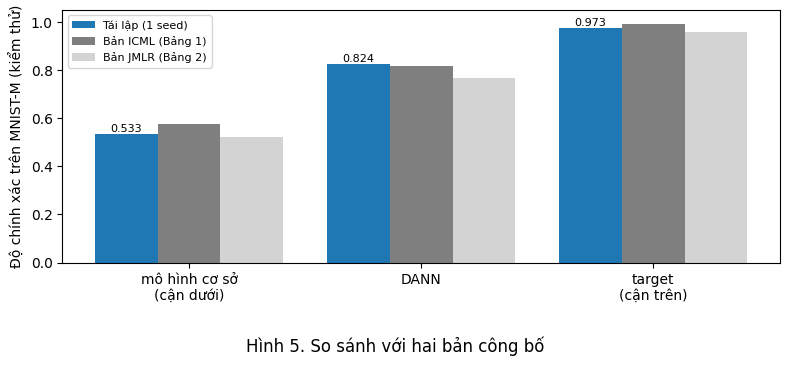

In [81]:
order = ["baseline", "dann", "target"]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - 0.27, a[order].mean(), 0.27, yerr=a[order].std(ddof=1) if len(a) > 1 else None,
       label=f"Tái lập ({len(a)} seed)", color="tab:blue")
ax.bar(x, PAPER.iloc[:, 0], 0.27, label=PAPER.columns[0], color="tab:gray")
ax.bar(x + 0.27, PAPER.iloc[:, 1], 0.27, label=PAPER.columns[1], color="lightgray")
for i, v in enumerate(a[order].mean()):
    ax.text(i - 0.27, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x, ["mô hình cơ sở\n(cận dưới)", "DANN", "target\n(cận trên)"])
ax.set_ylim(0, 1.05); ax.set_ylabel("Độ chính xác trên MNIST-M (kiểm thử)"); ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Hình 5. So sánh với hai bản công bố", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.2. Diễn biến theo epoch

Hình 6 vẽ $a_S$, $a_T$ của mô hình cơ sở và DANN, cùng $a_d$ của DANN theo epoch (seed đầu tiên trong `SEEDS`).
Đường nét đứt đánh dấu epoch $e^*$ do quy tắc ở mục 6 chọn.

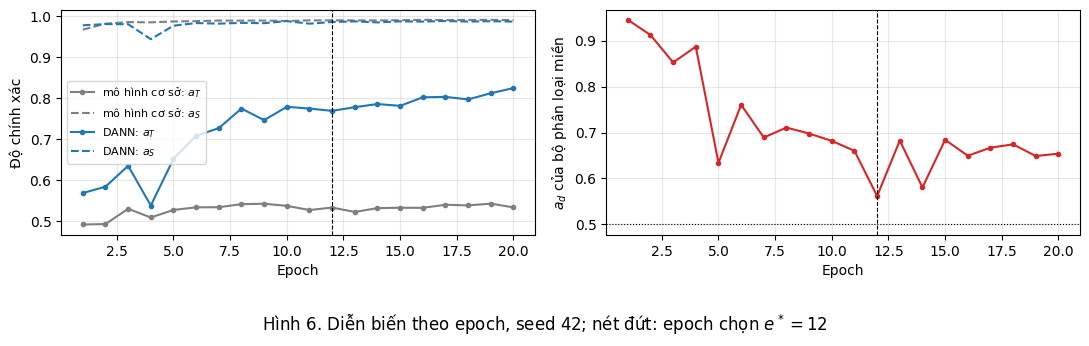

In [82]:
s0 = SEEDS[0]
H = {r["method"]: pd.DataFrame(r["history"]) for r in RESULTS if r["seed"] == s0}
e_star = next(r["selected"]["epoch"] for r in RESULTS if r["seed"] == s0 and r["selected"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for m, lbl, c in [("baseline", "mô hình cơ sở", "tab:gray"), ("dann", "DANN", "tab:blue")]:
    ax[0].plot(H[m].epoch, H[m].target_test_acc, "-o", ms=3, color=c, label=f"{lbl}: $a_T$")
    ax[0].plot(H[m].epoch, H[m].source_test_acc, "--", color=c, label=f"{lbl}: $a_S$")
ax[0].set_ylabel("Độ chính xác"); ax[0].legend(fontsize=8)
ax[1].plot(H["dann"].epoch, H["dann"].domain_acc, "-o", ms=3, color="tab:red")
ax[1].axhline(0.5, color="k", lw=0.8, ls=":")
ax[1].set_ylabel("$a_d$ của bộ phân loại miền")
for a_ in ax:
    a_.axvline(e_star, color="k", ls="--", lw=0.8)
    a_.set_xlabel("Epoch"); a_.grid(alpha=0.3)
fig.suptitle(f"Hình 6. Diễn biến theo epoch, seed {s0}; nét đứt: epoch chọn $e^* = {e_star}$", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.3. Phân phối đặc trưng (t-SNE)

Ganin và Lempitsky (2015, Hình 3) chiếu đặc trưng ở đầu ra bộ trích đặc trưng xuống hai chiều bằng t-SNE, bản
Barnes-Hut của van der Maaten (2013), tô màu theo miền, và ghi nhận độ chính xác trên miền đích tương ứng chặt
chẽ với mức chồng lấn giữa phân phối của hai miền. Hình 7 làm lại phép chiếu cho 1.000 ảnh kiểm thử mỗi miền,
với đặc trưng 768 chiều của $G_f$. `sklearn.manifold.TSNE` cài t-SNE của van der Maaten và Hinton (2008) và mặc
định dùng thuật toán Barnes-Hut.

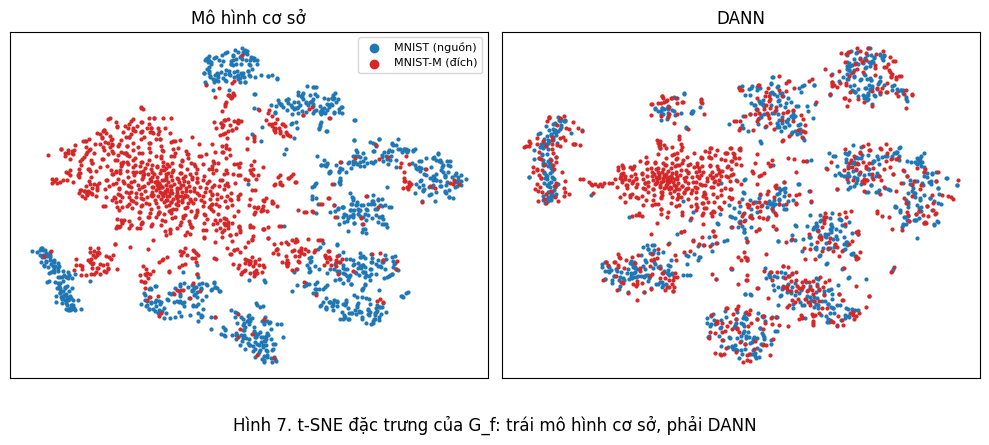

In [83]:
from sklearn.manifold import TSNE

src_test = get_dataset("mnist", DATA_DIR, train=False, mean=MEAN)
tgt_test = get_dataset("mnist_m_gen", DATA_DIR, train=False, mean=MEAN)
idx_s = torch.randperm(len(src_test), generator=torch.Generator().manual_seed(0))[:1000].tolist()
idx_t = torch.randperm(len(tgt_test), generator=torch.Generator().manual_seed(1))[:1000].tolist()


@torch.no_grad()
def feats(model):
    model.eval()
    xs = torch.stack([src_test[i][0] for i in idx_s]).to(device)
    xt = torch.stack([tgt_test[i][0] for i in idx_t]).to(device)
    return torch.cat([model.features(xs), model.features(xt)]).cpu().numpy()


fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
for a_, m, title in zip(ax, ["baseline", "dann"], ["Mô hình cơ sở", "DANN"]):
    z = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(feats(MODELS[(m, s0)]))
    a_.scatter(*z[:1000].T, s=4, c="tab:blue", label="MNIST (nguồn)")
    a_.scatter(*z[1000:].T, s=4, c="tab:red", label="MNIST-M (đích)")
    a_.set_title(title); a_.set_xticks([]); a_.set_yticks([])
ax[0].legend(markerscale=3, fontsize=8)
fig.suptitle("Hình 7. t-SNE đặc trưng của G_f: trái mô hình cơ sở, phải DANN", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 8.4. Ma trận nhầm lẫn và ví dụ

Ma trận nhầm lẫn (confusion matrix) của mô hình cơ sở và DANN trên 10.000 ảnh kiểm thử MNIST-M: hàng là nhãn
thật, cột là nhãn dự đoán, mỗi hàng chuẩn hóa về tổng 1.

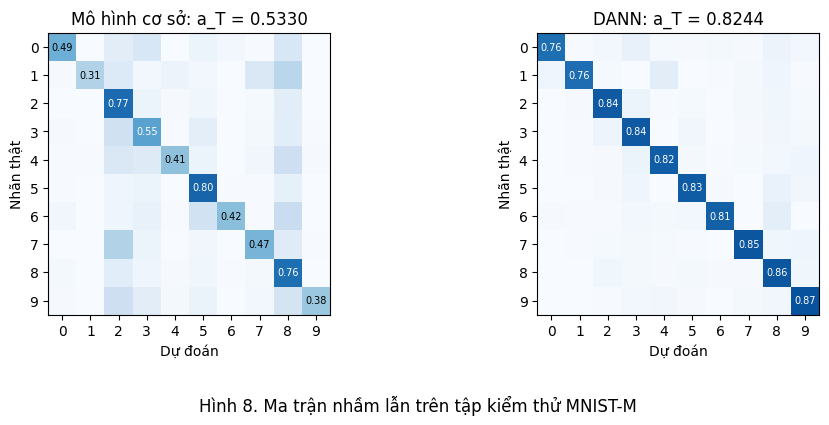

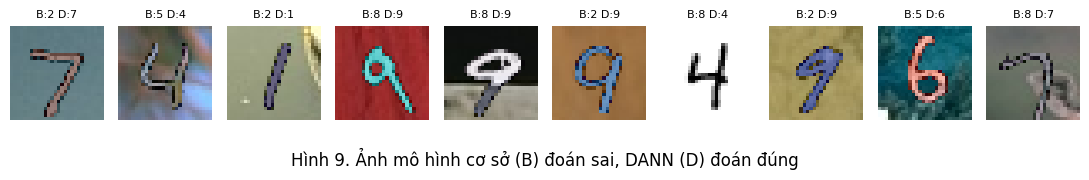

Số ảnh mô hình cơ sở sai, DANN đúng: 3404; mô hình cơ sở đúng, DANN sai: 490


In [84]:
@torch.no_grad()
def predict(model, ds):
    model.eval()
    loader = make_loader(ds, 512, torch.Generator().manual_seed(0), shuffle=False, workers=0)
    return torch.cat([model(x.to(device)).argmax(1).cpu() for x, _ in loader])


pred = {m: predict(MODELS[(m, s0)], tgt_test) for m in ["baseline", "dann"]}
yT = torch.tensor(tgt_test.labels)
yt = yT.numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 4.4))
for a_, m, title in zip(ax, ["baseline", "dann"], ["Mô hình cơ sở", "DANN"]):
    cm = np.zeros((10, 10))
    np.add.at(cm, (yt, pred[m].numpy()), 1)
    cm /= cm.sum(1, keepdims=True)
    a_.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    for i in range(10):
        a_.text(i, i, f"{cm[i, i]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if cm[i, i] > 0.5 else "black")
    a_.set_title(f"{title}: a_T = {(pred[m] == yT).float().mean().item():.4f}")
    a_.set_xticks(range(10)); a_.set_yticks(range(10))
    a_.set_xlabel("Dự đoán"); a_.set_ylabel("Nhãn thật")
fig.suptitle("Hình 8. Ma trận nhầm lẫn trên tập kiểm thử MNIST-M", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

fixed = torch.where((pred["baseline"] != yT) & (pred["dann"] == yT))[0][:10].numpy()
fig, ax = plt.subplots(1, len(fixed), figsize=(1.1 * len(fixed), 1.8))
for a_, i in zip(np.atleast_1d(ax), fixed):
    a_.imshow(mnistm_te[i]); a_.axis("off")
    a_.set_title(f"B:{pred['baseline'][i].item()} D:{pred['dann'][i].item()}", fontsize=8)
fig.suptitle("Hình 9. Ảnh mô hình cơ sở (B) đoán sai, DANN (D) đoán đúng", y=0.01)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
print(f"Số ảnh mô hình cơ sở sai, DANN đúng: {((pred['baseline'] != yT) & (pred['dann'] == yT)).sum().item()}; "
      f"mô hình cơ sở đúng, DANN sai: {((pred['baseline'] == yT) & (pred['dann'] != yT)).sum().item()}")

### 8.5. Đối chiếu với kết quả của kho mã

Kho mã [dann-mnist-mnistm](https://github.com/ThuanNP/dann-mnist-mnistm) huấn luyện bằng `python -m da_demo.train`
trên GPU NVIDIA RTX A4000 Laptop (torch 2.14.0+cu130), ba seed (42, 43, 44) cho mỗi cách tiền xử lý, tổng cộng 18
lần huấn luyện (`runs/gen-half`, `runs/gen-mean`). Notebook dùng cùng mã, cùng seed và cùng bộ nạp dữ liệu, nên
trên cùng GPU và cùng phiên bản torch, CUDA, cuDNN, kết quả từng seed được kỳ vọng trùng với kho mã; chạy lại
1.200 bước đầu của DANN seed 42 bằng mã của kho cho mất mát trùng từng chữ số với nhật ký đã lưu. Trên GPU T4 của Colab hoặc
với phiên bản thư viện khác, phép tính dấu phẩy động có thể khác nên kết quả có thể lệch nhỏ. Bảng dưới ghi
trung bình ± độ lệch chuẩn mẫu của độ chính xác trên tập kiểm thử MNIST-M, đặt cạnh kết quả của notebook.

In [85]:
REPO = pd.DataFrame({
    "kho mã, trừ 0,5": ["0,5401 ± 0,0269", "0,8061 ± 0,0280", "0,7681 ± 0,0485", "0,9726 ± 0,0003"],
    "kho mã, trừ trung bình": ["0,5144 ± 0,0335", "0,7996 ± 0,0091", "0,7533 ± 0,0571", "0,9730 ± 0,0006"]},
    index=["baseline", "dann", "dann (epoch chọn)", "target"])
dec = lambda v: f"{v:.4f}".replace(".", ",")
fmt = lambda m, s: dec(m) + (f" ± {dec(s)}" if not np.isnan(s) else "")
REPO[f"notebook, NORM = {NORM} ({len(a)} seed)"] = [
    fmt(a[c].mean(), a[c].std(ddof=1) if len(a) > 1 else np.nan) for c in REPO.index]
display(REPO)

,"kho mã, trừ 0,5","kho mã, trừ trung bình","notebook, NORM = half (1 seed)"
baseline,"0,5401 ± 0,0269","0,5144 ± 0,0335","0,5330"
dann,"0,8061 ± 0,0280","0,7996 ± 0,0091","0,8244"
dann (epoch chọn),"0,7681 ± 0,0485","0,7533 ± 0,0571","0,7688"
target,"0,9726 ± 0,0003","0,9730 ± 0,0006","0,9729"


## 9. Kết luận và giới hạn

- Với tiền xử lý trừ 0,5 ở mỗi kênh (`NORM = "half"`), trung bình ba seed của kho mã cho độ chính xác trên MNIST-M
  tăng từ 0,540 của mô hình cơ sở lên 0,806 với DANN ở epoch cuối, nằm giữa mốc 0,8149 của bản ICML và
  0,7666 của bản JMLR. Khoảng tin cậy 95% theo phân phối t (0,737–0,876) chứa cả hai mốc, nên ba seed chưa đủ để
  phân biệt. DANN thu hẹp khoảng 61,5% khoảng cách tới cận trên. Độ chính xác trên MNIST giảm từ 0,991 xuống 0,987. Độ lệch chuẩn giữa
  ba seed khoảng 0,03, nên kết quả của một seed như ở mục 8 có thể lệch vài điểm phần trăm quanh mức trung bình.
- Với tiền xử lý trừ trung bình kênh (`NORM = "mean"`), độ chính xác tăng từ 0,514 lên 0,800 và DANN thu hẹp
  khoảng 62,2% khoảng cách tới cận trên; khoảng tin cậy 95% (0,777–0,822) chứa mốc ICML và nằm trên
  mốc JMLR; khoảng này dựa trên độ lệch chuẩn ước lượng từ ba giá trị (khoảng 0,009, so với 0,028 khi trừ 0,5)
  nên chỉ mang tính mô tả.
- Trong sáu lần huấn luyện DANN của kho mã, từ epoch 10 trở đi $a_d$ nằm trong khoảng 0,54 đến 0,71 thay vì về
  0,5: bộ phân loại miền vẫn phân biệt được một phần hai miền, tức đặc trưng chưa bất biến hoàn toàn theo miền.
- Ở cả sáu lần huấn luyện đó, epoch chọn theo quy tắc không dùng nhãn đích cho $a_T$ thấp hơn epoch cuối: trung
  bình 0,768 so với 0,806 khi trừ 0,5 và 0,753 so với 0,800 khi trừ trung bình. Các epoch được chọn nằm trong
  khoảng epoch 8 đến 13.

Giới hạn:

- MNIST-M dựng lại theo phép trộn của Ganin và Lempitsky; hai bản công bố không nêu cách chọn ảnh nền và cắt mảnh,
  nên dữ liệu và độ khó của miền đích có thể khác bản của các tác giả.
- Ba chi tiết hai bản công bố không nêu (số seed, cách tính trung bình khi tiền xử lý, số bước huấn luyện) được chọn như
  mục 2.
- Kết quả phụ thuộc seed, GPU và phiên bản thư viện.

## Tài liệu tham khảo

- Arbelaez, P., Maire, M., Fowlkes, C., & Malik, J. (2011). Contour detection and hierarchical image
  segmentation. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 33*(5), 898-916.
- Ben-David, S., Blitzer, J., Crammer, K., & Pereira, F. (2006). Analysis of representations for domain
  adaptation. *Advances in Neural Information Processing Systems 19*.
- Ganin, Y., & Lempitsky, V. (2015). Unsupervised domain adaptation by backpropagation. *Proceedings of the
  32nd International Conference on Machine Learning*, PMLR 37, 1180-1189. [arXiv:1409.7495](https://arxiv.org/abs/1409.7495)
- Ganin, Y., Ustinova, E., Ajakan, H., Germain, P., Larochelle, H., Laviolette, F., Marchand, M., & Lempitsky, V.
  (2016). Domain-adversarial training of neural networks. *Journal of Machine Learning Research, 17*(59), 1-35.
  [arXiv:1505.07818](https://arxiv.org/abs/1505.07818)
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document
  recognition. *Proceedings of the IEEE, 86*(11), 2278-2324.
- van der Maaten, L. (2013). Barnes-Hut-SNE. *arXiv preprint*. [arXiv:1301.3342](https://arxiv.org/abs/1301.3342)
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning
  Research, 9*, 2579-2605.